# Modèles avancés — viser ~90 % de R² (french-second-hand-cars)

Le linéaire plafonne à R² ~0,73. Deux leviers pour monter :
1. **Log-cible** : prédire `log(prix)` au lieu du prix. Les prix sont très étalés (3k → 295k) ; le log rend la relation plus linéaire et corrige le « cône ».
2. **Modèles non linéaires** : `RandomForest` (bagging d'arbres) et `HistGradientBoosting` (boosting). Ils captent la dépréciation non linéaire que le linéaire rate.

**Validation croisée (cv=5)** : on ne juge pas sur un seul découpage. On regarde le **R² moyen ± écart-type** sur 5 découpes → détecte le surapprentissage.

> Rappel BC04 : les arbres sont plus performants mais **moins interprétables** que le linéaire. On garde donc `ElasticNet` comme référence explicable.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "../../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from features import clean_cars, load_premium_table, add_brand_features

RAW = "../../data/french-second-hand-cars/raw/French_second_hand_cars.csv"
REF = "../../references/premium_brand.csv" 

## 🟦 1. PRÉPROCESSING — nettoyage + features + split

In [2]:
df = clean_cars(RAW)
df = add_brand_features(df, load_premium_table(REF))

features = ["age", "kilometrage", "puissance_din", "puissance_fisc",
            "nombredeportes", "nombredeplaces",
            "niveau", "boite_auto", "garantie_constructeur", "garantie_mois"]

data = df[features + ["price"]].dropna(subset=["price"])
X, y = data[features], data["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (1872, 10) | test: (468, 10)


## 🟦 2. Levier 1 — pourquoi `log(prix)` ?

Les prix vont de 3 000 € à 295 000 €. Un modèle qui minimise l'erreur au carré se fait
« tirer » par les voitures très chères. Prédire `log(prix)` **compresse** cette échelle :
une erreur de 10 % pèse pareil sur une Twingo et sur une Porsche.

On utilise `TransformedTargetRegressor` : il applique `log1p` avant d'entraîner et
`expm1` sur les prédictions → **les scores restent en euros**, comparables aux notebooks précédents.

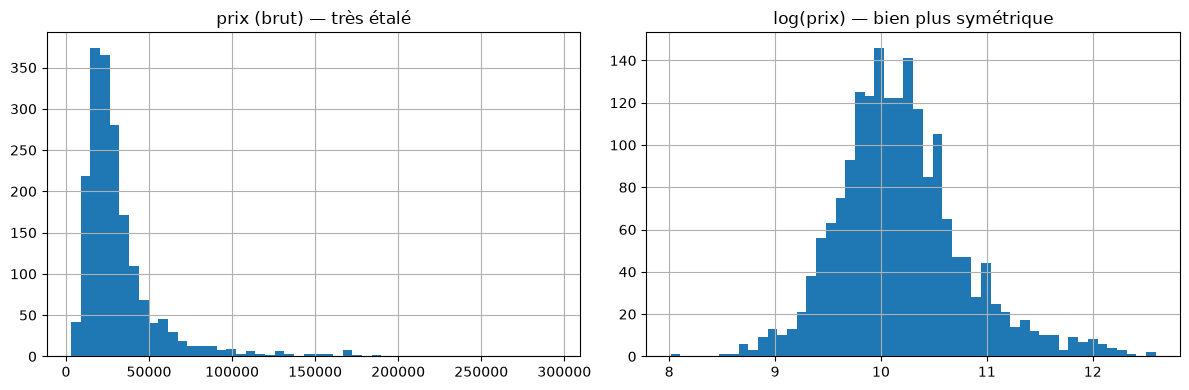

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
y_train.hist(bins=50, ax=ax[0]); ax[0].set_title("prix (brut) — très étalé")
np.log1p(y_train).hist(bins=50, ax=ax[1]); ax[1].set_title("log(prix) — bien plus symétrique")
plt.tight_layout(); plt.show()

## 🟩🟥 3. Panel de modèles (log-cible) + validation croisée

- **ElasticNet** : référence linéaire interprétable (Imputer + Scaler).
- **RandomForest** : moyenne de nombreux arbres (bagging).
- **HistGradientBoosting** : arbres construits en cascade (boosting), gère les NA nativement.

Chaque modèle est enveloppé pour prédire en log-cible. On mesure le R² en cv=5 (robustesse)
**et** sur le test final.

In [4]:
def log_model(estimator):
    # log-cible : entraîne sur log(prix), prédit en euros
    return TransformedTargetRegressor(regressor=estimator, func=np.log1p, inverse_func=np.expm1)

# ElasticNet : l'alpha doit être petit sur la cible log (variance faible) -> GridSearch
enet_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=10000)),
])
enet_grid = GridSearchCV(
    enet_pipe,
    {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1], "model__l1_ratio": [0.1, 0.5, 0.9]},
    cv=5, scoring="r2", n_jobs=-1,
)

modeles = {
    "ElasticNet (log)": log_model(enet_grid),
    "RandomForest (log)": log_model(Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
    ])),
    "HistGradientBoosting (log)": log_model(
        HistGradientBoostingRegressor(random_state=42)  # gère les NA tout seul
    ),
}

In [5]:
lignes = []
for nom, model in modeles.items():
    # robustesse : R² en validation croisée (5 découpes) sur le TRAIN
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
    # score final sur le test jamais vu
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    lignes.append({
        "modèle": nom,
        "R² CV (moy)": round(cv.mean(), 3),
        "R² CV (±std)": round(cv.std(), 3),
        "MAE test (€)": round(mean_absolute_error(y_test, pred)),
        "RMSE test (€)": round(np.sqrt(mean_squared_error(y_test, pred))),
        "R² test": round(r2_score(y_test, pred), 3),
    })

resultats = pd.DataFrame(lignes).sort_values("R² test", ascending=False)
resultats

,modèle,R² CV (moy),R² CV (±std),MAE test (€),RMSE test (€),R² test
2,HistGradientBoosting (log),0.880,0.028,5444,11972,0.844
1,RandomForest (log),0.870,0.026,5823,12000,0.843
0,ElasticNet (log),0.797,0.050,7131,15103,0.751


## 🟥 4. Meilleur modèle — réel vs prédit

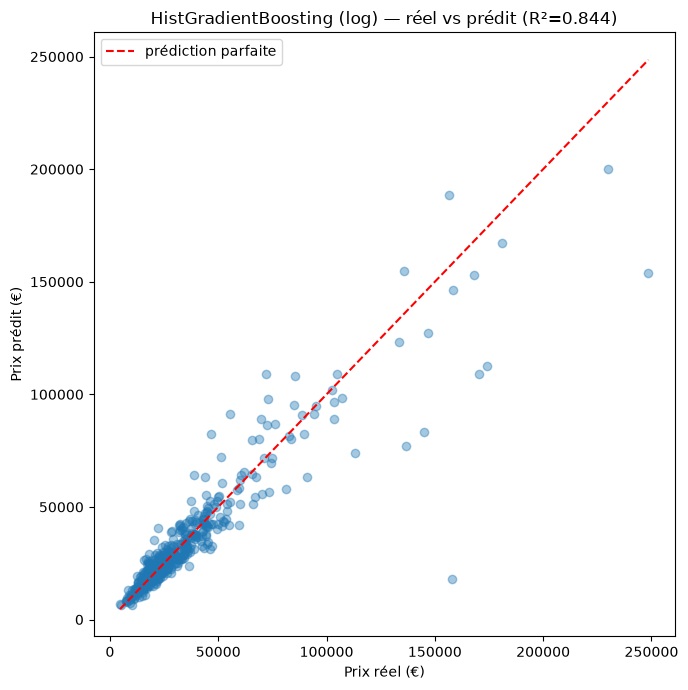

In [6]:
best_nom = resultats.iloc[0]["modèle"]
best = modeles[best_nom]
best.fit(X_train, y_train)
pred = best.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, pred, alpha=0.4)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="prédiction parfaite")
plt.xlabel("Prix réel (€)"); plt.ylabel("Prix prédit (€)")
plt.title(f"{best_nom} — réel vs prédit (R²={r2_score(y_test, pred):.3f})")
plt.legend(); plt.tight_layout(); plt.show()

## 🟥 5. Importance des features (meilleur modèle à arbres)

Les arbres fournissent une **importance** par feature (combien elle aide à découper).
Moins précis que les coefficients linéaires, mais donne l'intuition de ce qui compte.

In [7]:
from sklearn.inspection import permutation_importance

r = permutation_importance(best, X_test, y_test, n_repeats=10,
                           random_state=42, scoring="r2", n_jobs=-1)
imp = pd.Series(r.importances_mean, index=features).sort_values(ascending=False)
print("Importance par permutation (chute de R² si on mélange la feature) :")
print(imp.round(3).to_string())

Importance par permutation (chute de R² si on mélange la feature) :
puissance_din            0.573
puissance_fisc           0.242
niveau                   0.191
kilometrage              0.092
age                      0.089
nombredeportes           0.018
boite_auto               0.016
nombredeplaces           0.004
garantie_mois            0.001
garantie_constructeur    0.001


## Lecture (BC04)

- **Log-cible + arbres** : gros gain attendu vs le linéaire (R² ~0,73 → viser 0,85–0,92).
- Le **R² CV** (moyenne ± écart-type) est le chiffre honnête : si test ≫ CV, c'est du surapprentissage.
- **Compromis interprétabilité / performance** : `ElasticNet` reste lisible (coefficients en €), les arbres sont plus performants mais « boîte noire » (on a l'importance, pas l'effet chiffré).
- Une partie du R² vient des **voitures chères** (peu nombreuses, forte variance) — à garder en tête.
- **Prochaine étape produit** : passer du prix ponctuel à une **fourchette + incertitude** (exigence OscarIA), pas encore traitée.